# <font color=green>Training Models to Predict Lmax w/ESM-2 Embeddings</font>
## Modeling spectral tuning sites of opsin proteins based on amino-acid sequence embeddings...  

In [398]:
# importing deepBreaks libraries 
from deepBreaks.utils import get_models, get_scores, get_simp_params, make_pipeline
from deepBreaks.preprocessing import MisCare, ConstantCare, URareCare, CustomOneHotEncoder
from deepBreaks.preprocessing import FeatureSelection, CollinearCare
from deepBreaks.preprocessing import read_data
from deepBreaks.models import model_compare_cv, finalize_top, importance_from_pipe, mean_importance, summarize_results
from deepBreaks.visualization import plot_scatter, dp_plot, plot_imp_model, plot_imp_all
from deepBreaks.preprocessing import write_fasta
import warnings
import datetime
import os
import shutil 

In [399]:
warnings.filterwarnings("ignore")
warnings.simplefilter('ignore')

In [400]:
#assign your path to folder containing all the datasplits
path = './vpod_1.3'
# path to sequences of interest
seqFileName = f'{path}/wt_vert_aligned_VPOD_1.3_het.fasta' 
# path to corresponding metadata of interest
metaDataFileName = f'{path}/wt_vert_meta.tsv' 

# name of the phenotype
mt = 'Lambda_Max'

# type of the sequences
seq_type = 'aa'

# type of the analysis if it is a classification model, then we put cl instead of reg
ana_type = 'reg' 

gap_threshold = 0.60

#Whether or not you want to drop the reference sequence from the training data- Usually 'Bovine' or 'Squid'
drop_ref = False

In [401]:
# making a unique directory for saving the reports of the analysis
print('direcory preparation')
dt_label = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
metaFile = metaDataFileName.split('/')[2]
#print(seqFile)
metaFile = metaFile.split('.')[0]
#print(seqFile)
report_dir = str(metaFile +'_' + dt_label)
os.makedirs(report_dir)

direcory preparation


In [402]:
%%time
print('reading meta-data')
# importing metadata
meta_data = read_data(metaDataFileName, seq_type = None, is_main=False)

reading meta-data
CPU times: total: 0 ns
Wall time: 25.4 ms


In [403]:
import numpy as np
import csv
import pandas as pd

**Attention**: metadata and sequences data should have the names as their row names and for each sequence their must be a value in the meta data file.

In [404]:
print('metadata looks like this:')
meta_data.head()

metadata looks like this:


,Lambda_Max,Species,Opsin_Family,Phylum,Class,Accession,Mutations,Protein,RefId
Seq_Id,,,,,,,,,
Bovine,500.0,Bos_tarus,Rh1,Chordata,Mammalia,NM_001014890,NaN,MNGTEGPNFYVPFSNKTGVVRSPFEAPQYYLAEPWQFSMLAAYMFL...,NaN
S1,502.0,Neoniphon_sammara,Rh1,Chordata,Actinopteri,U57536.1,NaN,MNGTEGPYFYVPMVNTTGVVRSPYEYPQYYLVNPAAFAVLGAYMFF...,160.0
S2,502.0,Neoniphon_argenteus,Rh1,Chordata,Actinopteri,U57540.1,NaN,TEGPYFYVPMVNTTGIVRSPYEYPQYYLVNPAAYAVLGAYMFFLII...,160.0
S3,481.0,Neoniphon_aurolineatus,Rh1,Chordata,Actinopteri,U57541.1,NaN,TEGPDFYIPMVNTSGLVRSPYEYPQYYLVNPAAFAFLGAYMFFLII...,160.0
S4,494.0,Sargocentron_punctatissimum,Rh1,Chordata,Actinopteri,U57543.1,NaN,TEGPFFYIPMVNTSGVVRSPYEYPQYYLVNPAAYAILGAYMFFLII...,160.0


In [405]:
meta_data.shape

(319, 9)

In [406]:
use_ev = False
y = meta_data['Lambda_Max'].to_list()
if use_ev == True:
    y = 1239.8 / np.array(y)
    

In [407]:
import random
from collections import Counter
#from tqdm import tqdm
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import esm


from sklearn.decomposition import PCA

In [408]:
index_names = meta_data.index.to_list()

In [409]:
len(index_names)

319

In [410]:
OPS_EMB_PATH = "./esm_embed_vpod_1.3/wt_vert_embeds" # Path to directory of embeddings
EMB_LAYER = 36

In [411]:
Xs = []
for indx in index_names:
    try:
        fn = f'{OPS_EMB_PATH}/{indx}.pt'
        embs = torch.load(fn)
        Xs.append(embs['mean_representations'][EMB_LAYER])
    except:
        pass
Xs = torch.stack(Xs, dim=0).numpy()
print(Xs.shape)

(319, 2560)


In [412]:
col_names = []
for col in range(Xs.shape[1]):
    col_names.append(f'p{col+1}')
 

In [413]:
tr2 = pd.DataFrame(data = list(Xs), index=index_names, columns=col_names)
tr2.head()

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p2551,p2552,p2553,p2554,p2555,p2556,p2557,p2558,p2559,p2560
Bovine,0.059214,0.010813,-0.006529,-0.075838,-0.074655,-0.092912,-0.058555,0.032751,0.085176,-0.078712,...,0.231578,-0.050421,0.043823,0.069265,0.155911,-0.006205,-0.113463,-0.005451,-0.107733,-0.056010
S1,0.062939,-0.000468,-0.003120,-0.070140,-0.080421,-0.090015,-0.059866,0.030625,0.091532,-0.064010,...,0.219869,-0.044966,0.036936,0.059839,0.127261,-0.010935,-0.101759,-0.002180,-0.099099,-0.031234
S2,0.062693,-0.000402,-0.004340,-0.070926,-0.076619,-0.082741,-0.060637,0.027515,0.087496,-0.062185,...,0.222073,-0.046514,0.034735,0.063130,0.124689,-0.009256,-0.103396,-0.002673,-0.103393,-0.029843
S3,0.066980,-0.000784,-0.000811,-0.055923,-0.069370,-0.078265,-0.067232,0.020540,0.093955,-0.058825,...,0.221942,-0.035928,0.038567,0.071809,0.126056,-0.013617,-0.105675,-0.018018,-0.098327,-0.010645
S4,0.066000,0.002472,-0.005060,-0.066283,-0.077588,-0.085850,-0.062982,0.025621,0.085087,-0.060813,...,0.222017,-0.044273,0.039175,0.064866,0.127466,-0.011442,-0.106146,-0.006641,-0.106339,-0.028421


In [414]:
num_pca_components = 100
pca = PCA(num_pca_components)
Xs_train_pca = pca.fit_transform(Xs)

In [415]:
col_names2 = []
for col in range(num_pca_components):
    col_names2.append(f'p{col}')
 

In [416]:
tr3 = pd.DataFrame(data = Xs_train_pca, index=index_names, columns=col_names2)
tr3

,p0,p1,p2,p3,p4,p5,p6,p7,p8,p9,...,p90,p91,p92,p93,p94,p95,p96,p97,p98,p99
Bovine,-0.511152,0.618817,0.124318,-0.065112,0.133694,0.063952,-0.093848,0.024064,0.037338,0.049237,...,0.003469,0.004666,0.000412,-0.009121,0.007107,0.000658,0.005415,0.019916,-0.026329,-0.017279
S1,-0.117401,0.387989,0.047280,0.084616,-0.122538,0.076629,0.137954,-0.179048,-0.018428,0.029223,...,0.002502,-0.000504,0.005981,0.001098,0.018926,0.005074,0.001068,0.001055,-0.009695,-0.005897
S2,-0.082370,0.427063,0.040966,0.092507,-0.147760,0.045426,0.115966,-0.192791,-0.020425,0.025102,...,0.006001,0.014252,-0.001200,0.008639,0.009974,0.004473,0.001937,0.002022,0.001901,-0.008959
S3,0.257290,0.499379,0.042562,0.065711,-0.178068,-0.027783,0.025835,-0.254870,-0.030295,0.034180,...,-0.007823,0.011875,-0.004631,-0.009473,-0.008340,-0.011756,-0.001969,-0.007964,0.008598,0.008819
S4,-0.011117,0.455238,0.069352,0.072487,-0.108027,0.024061,0.058415,-0.197910,-0.030528,0.031073,...,0.022650,0.008940,0.004855,-0.003257,0.002470,0.002447,0.004141,0.010886,0.004168,-0.005073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S314,-0.791641,0.450996,0.189772,-0.256588,0.211261,0.067399,0.039992,0.017917,-0.023393,0.050941,...,-0.007048,-0.005575,0.004718,0.003594,-0.005902,0.005551,-0.001937,0.006705,0.003539,-0.019205
S315,-0.957451,0.479255,0.197770,-0.241963,0.218830,0.085749,0.034902,0.022862,-0.031881,0.055510,...,-0.004502,-0.003601,0.002182,-0.001062,-0.009345,0.002682,-0.008164,0.011900,0.000348,-0.010801
S316,-1.007659,0.494928,0.198530,-0.217661,0.211342,0.112208,0.034977,0.019344,-0.021897,0.054871,...,-0.009868,0.000367,0.002142,-0.002398,-0.007310,0.010608,-0.010535,0.017491,-0.005896,-0.011813
S317,-1.123283,0.457824,0.235457,-0.232649,0.254490,0.129086,0.050687,0.078025,-0.017065,0.061419,...,-0.014492,-0.012669,0.005478,-0.009544,-0.007394,-0.008543,0.009025,0.004132,0.003088,-0.004500


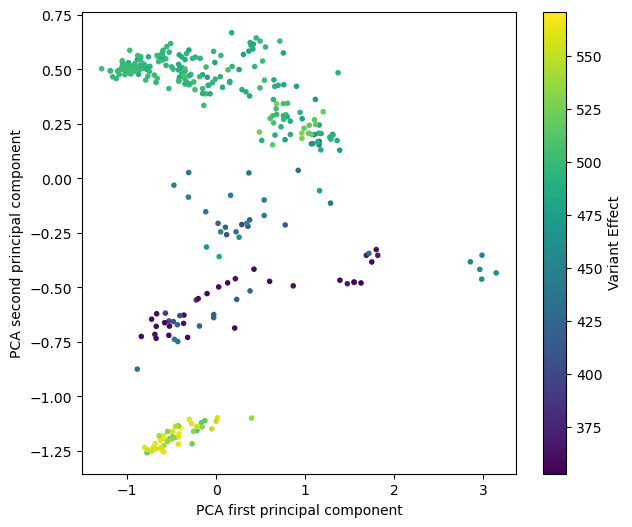

In [417]:
fig_dims = (7, 6)
fig, ax = plt.subplots(figsize=fig_dims)
sc = ax.scatter(Xs_train_pca[:,0], Xs_train_pca[:,1], c=y, marker='.')
ax.set_xlabel('PCA first principal component')
ax.set_ylabel('PCA second principal component')
plt.colorbar(sc, label='Variant Effect')

### Preprocessing
In this step, we do all these steps:
1. dropping columns with a number of missing values above a certain threshold  
2. dropping zero entropy columns  
3. imputing missing values with the mode of that column  
4. replacing cases with a frequency below a threshold (default 1.5%) with the mode of that column
5. dropping zero entropy columns
6. use statistical tests (each position against the phenotype) and drop columns with p-values below a threshold (default 0.25)
7. one-hot encode the remaining columns
8. calculate the pair-wise distance matrix for all of the columns
9. use the distance matrix for DBSCAN and cluster the correlated positions together
10. keep only one column (closes to center of each cluster) for each group and drop the rest from the training data set

In [418]:
prep_pipeline = make_pipeline(
    steps=[
        ('cc', ConstantCare()),
        ('feature_selection', FeatureSelection(model_type=ana_type, alpha=0.10, keep=False)),
        ('collinear_care', CollinearCare(dist_method='correlation', threshold=0.001, keep=False))
    ])

In [419]:
report, top = model_compare_cv(X=tr2, y=y, preprocess_pipe=prep_pipeline,
                               models_dict=get_models(ana_type=ana_type),
                               scoring=get_scores(ana_type=ana_type),
                               report_dir=report_dir,
                               cv=10, ana_type=ana_type, cache_dir=None)

Fitting rf...
Fitting Adaboost...
Fitting et...
Fitting gbr...
Fitting dt...
Fitting lr...
Fitting Lasso...
Fitting LassoLars...
Fitting BayesianRidge...
Fitting HubR...
Fitting lgbm...
Fitting xgb...


In [420]:
report

,R2,MAE,MSE,RMSE,MAPE
HubR,0.945441,7.107426,137.600713,11.437075,0.015891
BayesianRidge,0.941698,7.363520,144.733578,11.780664,0.016470
lgbm,0.939234,7.918990,158.319671,12.261530,0.017657
et,0.937719,8.118265,153.255964,12.163680,0.018160
lr,0.936684,8.002680,155.025249,12.214548,0.017737
rf,0.933678,8.658247,168.654170,12.689350,0.019316
Adaboost,0.929291,8.986865,172.460462,12.840263,0.019797
gbr,0.923567,8.620532,188.721270,13.499048,0.019255
xgb,0.893420,10.284326,264.981085,15.997856,0.023021
dt,0.848818,11.662147,384.717324,19.307340,0.026003


In [421]:
%%time
report2, top2 = model_compare_cv(X=tr3, y=y, preprocess_pipe=prep_pipeline,
                               models_dict=get_models(ana_type=ana_type),
                               scoring=get_scores(ana_type=ana_type),
                               report_dir=report_dir,
                               cv=10, ana_type=ana_type, cache_dir=report_dir)

Fitting rf...
Fitting Adaboost...
Fitting et...
Fitting gbr...
Fitting dt...
Fitting lr...
Fitting Lasso...
Fitting LassoLars...
Fitting BayesianRidge...
Fitting HubR...
Fitting lgbm...
Fitting xgb...
CPU times: total: 1.66 s
Wall time: 2.09 s


MAE = Mean Absolute Error

MSE = Mean Squared Error

RMSE = Rooted Mean Square Error

MAPE = Mean Absolute % Error - the average magnitude of error produced by a model, or how far off predictions are on average. A MAPE value of 20% means that the average absolute percentage difference between the predictions and the actuals is 20%

In [422]:
report2

,R2,MAE,MSE,RMSE,MAPE
et,0.900499,10.326643,248.176709,15.449698,0.023050
lgbm,0.883465,11.307051,287.249823,16.762128,0.025173
gbr,0.881371,11.191772,289.638047,16.602737,0.025000
rf,0.874293,11.082083,304.901248,17.022767,0.024855
xgb,0.870800,11.436120,314.382336,17.207985,0.025610
Adaboost,0.866480,13.179674,314.006014,17.501955,0.029176
BayesianRidge,0.845241,15.033722,379.593543,19.364863,0.033292
lr,0.845073,15.030458,379.827139,19.370396,0.033278
HubR,0.838930,14.886589,396.358517,19.740197,0.033035
LassoLars,0.832938,16.056326,421.658778,20.401216,0.035839


In [423]:
prep_pipeline = make_pipeline(
    steps=[
        ('cc', ConstantCare()),
        ('feature_selection', FeatureSelection(model_type=ana_type, alpha=0.10, keep=True)),
        ('collinear_care', CollinearCare(dist_method='correlation', threshold=0.001, keep=True))
    ])

In [424]:
modified_top = []
mtml = []
for model in top:
    modified_top.append(make_pipeline(steps=[('prep', prep_pipeline), model.steps[-1]]))
    my_top_models = str(model[1:])
    #print(my_top_models)
    my_top_models = my_top_models.split("'")[1]
    mtml.append(my_top_models)
    #print(my_top_models)

In [425]:
modified_top[0]

Pipeline(steps=[('prep',
                 Pipeline(steps=[('cc', ConstantCare()),
                                 ('feature_selection',
                                  FeatureSelection(alpha=0.1, keep=True,
                                                   model_type='reg')),
                                 ('collinear_care',
                                  CollinearCare(dist_method='correlation',
                                                keep=True,
                                                threshold=0.001))])),
                ('HubR', HuberRegressor(max_iter=2000, tol=0.0001))])

In [426]:
%%time
top = finalize_top(X=tr3, y=y, top_models=modified_top, grid_param={},report_dir=report_dir, cv=10)


Tuning HubR...
No Grid-Search Specified, fitting model to default parameters.
Tuning BayesianRidge...
No Grid-Search Specified, fitting model to default parameters.
Tuning lgbm...
No Grid-Search Specified, fitting model to default parameters.
Tuning et...
No Grid-Search Specified, fitting model to default parameters.
Tuning lr...
No Grid-Search Specified, fitting model to default parameters.
CPU times: total: 1.14 s
Wall time: 479 ms


In [427]:
import joblib
load_model = joblib.load(report_dir+'/et.pkl')